In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import numpy as np
import math 

In [11]:
df1 = pd.read_csv('cars.csv')
df2 = pd.read_csv('train.csv')

In [15]:
print(df1.head(5))

          Car       Model  Volume  Weight  CO2
0      Toyoty        Aygo    1000     790   99
1  Mitsubishi  Space Star    1200    1160   95
2       Skoda      Citigo    1000     929   95
3        Fiat         500     900     865   90
4        Mini      Cooper    1500    1140  105


In [17]:
df1.describe()

,Volume,Weight,CO2
count,36.000000,36.000000,36.000000
mean,1611.111111,1292.277778,102.027778
std,388.975047,242.123889,7.454571
min,900.000000,790.000000,90.000000
25%,1475.000000,1117.250000,97.750000
50%,1600.000000,1329.000000,99.000000
75%,2000.000000,1418.250000,105.000000
max,2500.000000,1746.000000,120.000000


In [19]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     36 non-null     object
 1   Model   36 non-null     object
 2   Volume  36 non-null     int64 
 3   Weight  36 non-null     int64 
 4   CO2     36 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.5+ KB


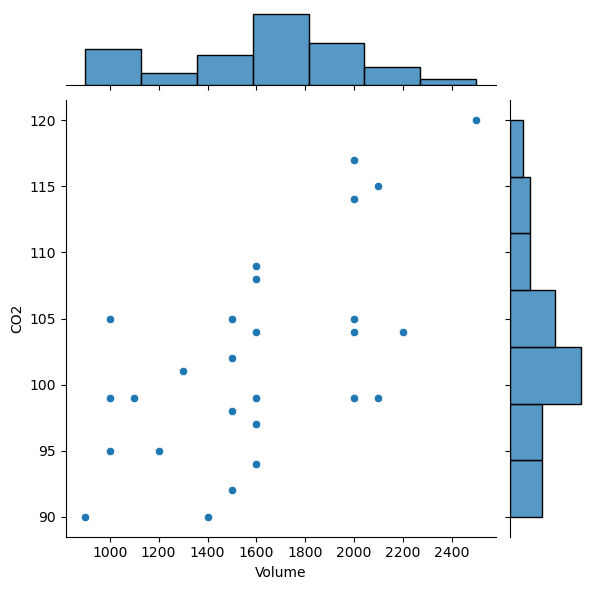

In [29]:
## EDA For this model 

sns.jointplot(x="Volume", y="CO2", data=df1,)

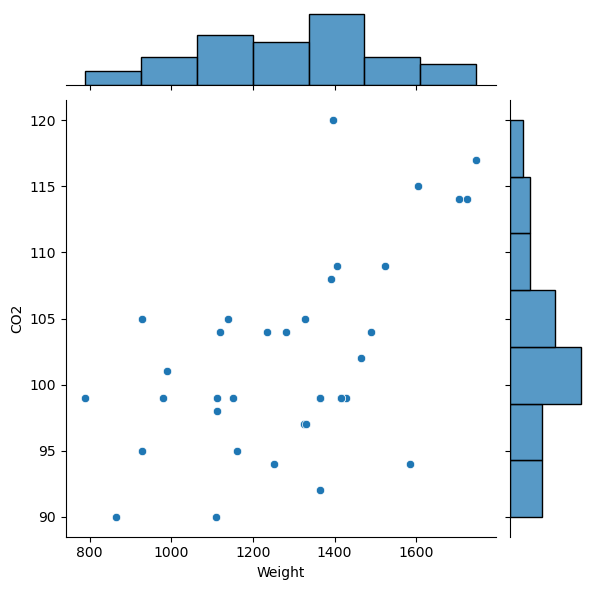

In [31]:
sns.jointplot(x="Weight", y="CO2", data=df1,)

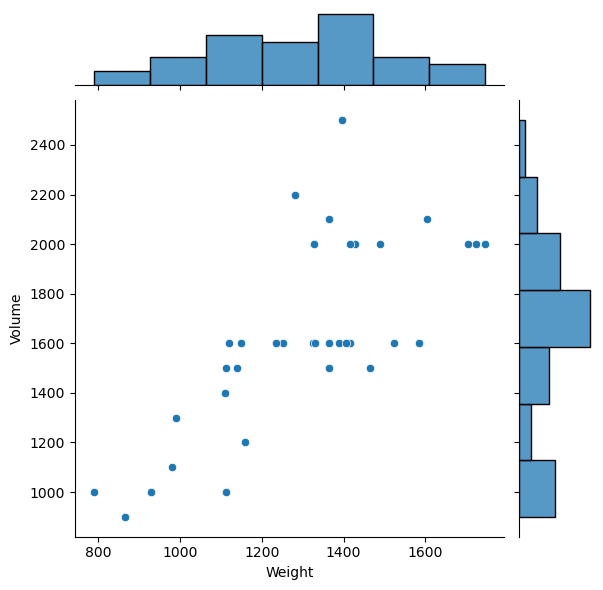

In [33]:
sns.jointplot(x="Weight", y="Volume", data=df1,)

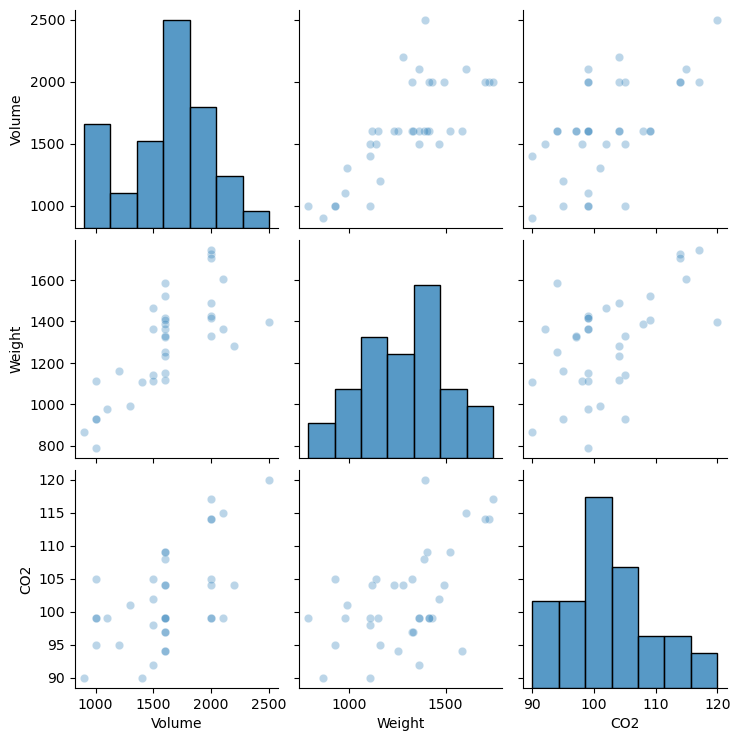

In [35]:
sns.pairplot(df1, kind='scatter', plot_kws={'alpha':0.3})

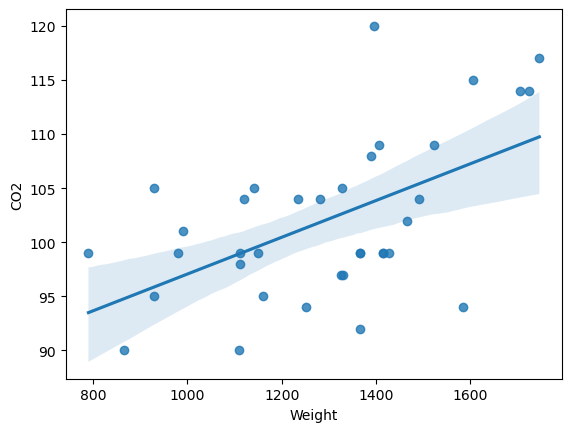

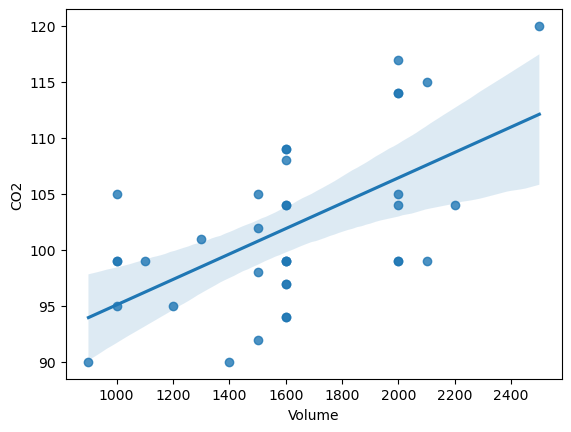

In [104]:
sns.regplot(x=df['Weight'], y=df['CO2'])
plt.show()

sns.regplot(x=df['Volume'], y=df['CO2'])
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [61]:
X=df1[['Weight']]
y=df1['CO2']

In [63]:
X_train ,X_test ,y_train, y_test = train_test_split(X, y , test_size=0.3,random_state=42)

In [65]:
ln = LinearRegression()

In [67]:
ln.fit(X_train, y_train)

LinearRegression()

In [69]:
ln.coef_

array([0.01256097])

In [76]:
coef = pd.DataFrame(
    ln.coef_,
    index=X.columns,
    columns=['Coef']
)

print(coef)
print(type(X))
print(X.columns)
print(ln.coef_)

            Coef
Weight  0.012561
<class 'pandas.core.frame.DataFrame'>
Index(['Weight'], dtype='object')
[0.01256097]


In [78]:
y_pred = ln.predict(X_test)

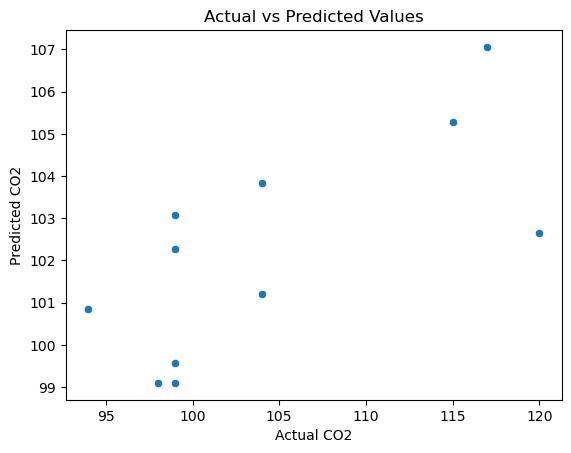

In [82]:
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted Values")
plt.show()

In [84]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [88]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 5.082822680372877
Mean Squared Error: 52.514215340605695
RMSE: 7.24666925839766


In [90]:
residuals = y_test - y_pred

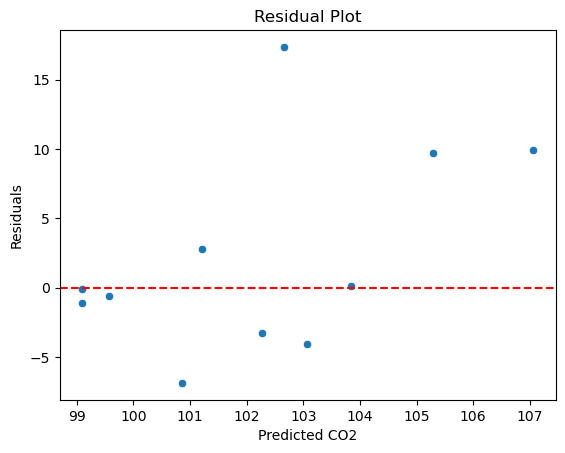

In [102]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted CO2")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [94]:
import pylab
import scipy.stats as stats

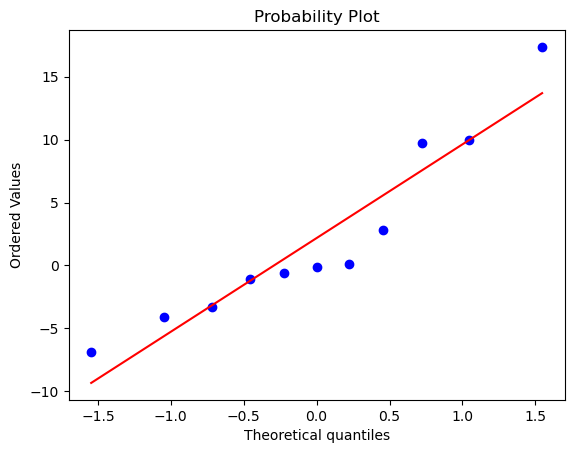

In [98]:
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

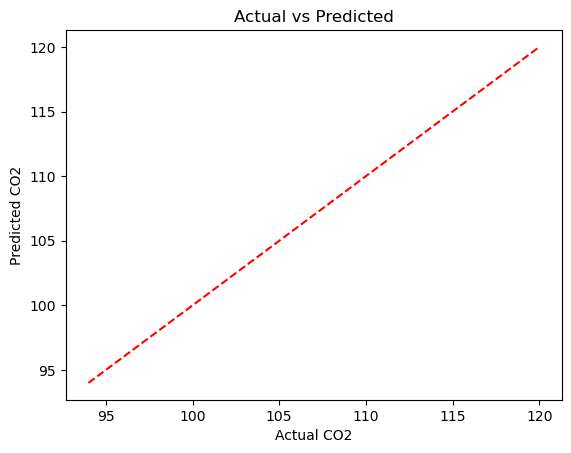

In [100]:
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted")
plt.show()